Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [2]:
library('tidymodels')


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [3]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [4]:

glimpse(diabetes_train)

Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 1, 5, 10, 10, 1, 8, 1, 5, 5, 6, 10, 4, 11,…
$ Glucose                  <dbl> 85, 89, 116, 115, 139, 103, 99, 97, 117, 109,…
$ BloodPressure            <dbl> 66, 66, 74, 0, 80, 30, 84, 66, 92, 75, 92, 78…
$ SkinThickness            <dbl> 29, 23, 0, 0, 0, 38, 0, 15, 0, 26, 0, 31, 33,…
$ Insulin                  <dbl> 0, 94, 0, 0, 0, 83, 0, 140, 0, 0, 0, 0, 192, …
$ BMI                      <dbl> 26.6, 28.1, 25.6, 35.3, 27.1, 43.3, 35.4, 23.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.167, 0.201, 0.134, 1.441, 0.183, 0.3…
$ Age                      <dbl> 31, 21, 30, 29, 57, 33, 50, 22, 38, 60, 28, 4…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

The `Outcome` variable is most suitable, as it takes only binary values (0 = no diabetes, 1 = diabetes) — exactly the kind of categorical response that logistic regression is designed to model.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column name | Description |
| :---------- | :---------- |
| Glucose     | Plasma glucose concentration a 2 hours in an oral glucose tolerance test         |
| BMI         | Body mass index (weight in kg/(height in m)^2)            |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

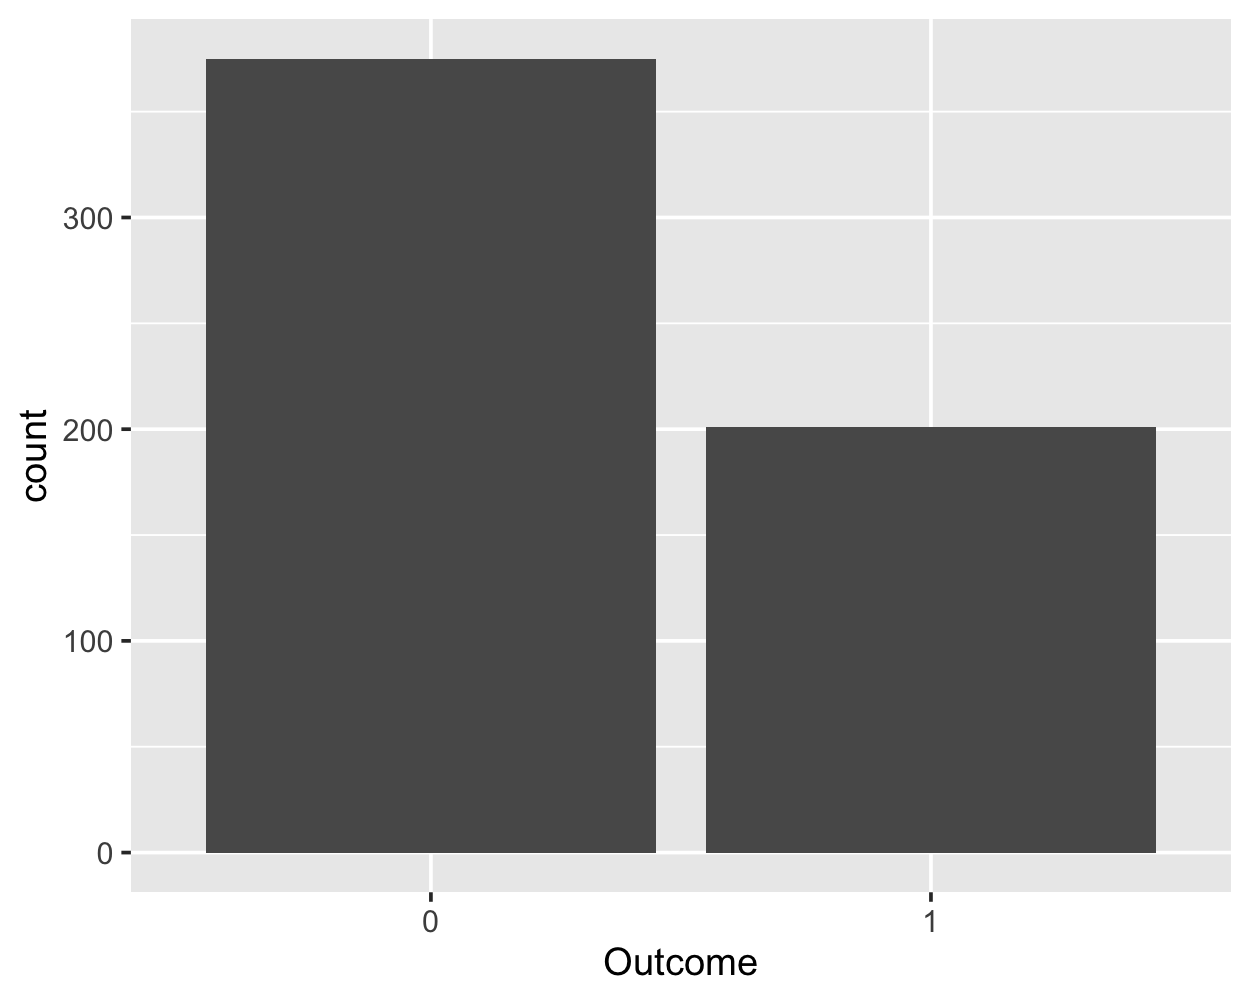

In [6]:
ggplot(diabetes_train, aes(x = Outcome)) + 
  geom_bar()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**

Not perfectly balanced, but close. It looks more like a 65/35 split rather than a 50/50 split.

Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [7]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,89.0
0,BMI,28.1
0,Glucose,116.0
0,BMI,25.6


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

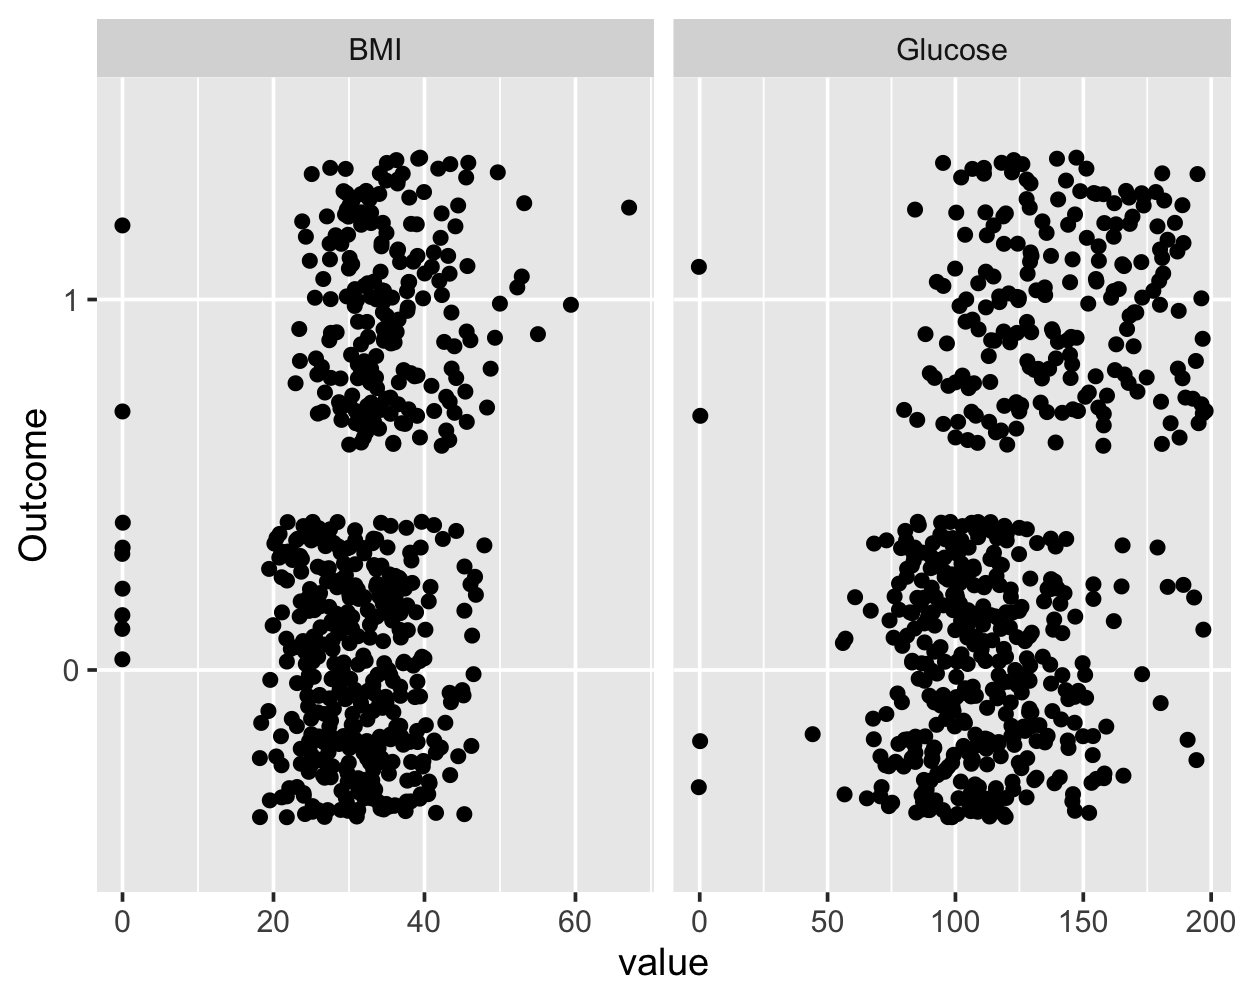

In [11]:

ggplot(plot_df, aes(x = value, y = Outcome)) +
geom_jitter() +
facet_wrap(~name, ncol = 2, scales = 'free_x')


❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

The values especially for BMI seem to be closer to zero. Without `scales = 'free_x'`, `facet_wrap` defaults to `scales = 'fixed'`, meaning both facets are forced to share the same x-axis range. Since `Glucose` and `BMI` have very different scales (Glucose ranges roughly 0-200, while BMI ranges roughly 0-70), the shared x-axis gets stretched to accommodate Glucose's larger range. This squishes the BMI panel's data into a narrow band on the left side of its facet, making it much harder to see the spread and pattern of the BMI values.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [20]:
mod = logistic_reg() |> set_engine('glm')


mod_fit = mod |> fit(Outcome ~ BMI + Glucose, data = diabetes_train)

tidy(mod_fit)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-7.12921140,0.674875428,-10.563744,4.388021e-26
BMI,0.07334306,0.015015030,4.884643,1.036165e-06
Glucose,0.03304683,0.003661146,9.026362,1.774743e-19


Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [22]:

diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)
diabetes_test_wPred |> head()


.pred_class,.pred_0,.pred_1,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,0.4437279,0.55627212,6,148,72,35,0,33.6,0.627,50,1
1,0.3481340,0.65186602,8,183,64,0,0,23.3,0.672,32,1
0,0.9070321,0.09296787,3,78,50,32,88,31.0,0.248,26,1
1,0.1654840,0.83451598,2,197,70,45,543,30.5,0.158,53,1
0,0.6761996,0.32380037,4,110,92,0,0,37.6,0.191,30,0
0,0.5207203,0.47927970,3,126,88,41,235,39.3,0.704,27,0


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [23]:
diabetes_test_wPred = augment(mod_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 115  28
         1  10  39

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

* 67 had diabetes in the test data 
* 39 of those predicted with diabetes were correctly predicted by the model
* 10 of those predicted to have diabetes did not have diabetes